In [16]:
import torch
import argparse
import torch.nn as nn
import torch.optim as optim
import time

from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/ResNetModel/src')
from model import build_model
from findmydatasets import get_datasets, get_data_loaders
from utils import save_model, save_plots

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [18]:
# Construct the argument parser.
parser = argparse.ArgumentParser()
parser.add_argument(
    '-e', '--epochs', type=int, default=35,
    help='Number of epochs to train our network for'
)
parser.add_argument(
    '-lr', '--learning-rate', type=float,
    dest='learning_rate', default=0.001,
    help='Learning rate for training the model'
)
args = vars(parser.parse_args([]))

In [19]:
# Training function.
def train(model, trainloader, optimizer, criterion):
    model.train()
    print('Training')
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    for i, data in tqdm(enumerate(trainloader), total=len(trainloader)):
        counter += 1
        image, labels = data
        image = image.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        # Forward pass.
        outputs = model(image)
        # Calculate the loss.
        loss = criterion(outputs, labels)
        train_running_loss += loss.item()
        # Calculate the accuracy.
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == labels).sum().item()
        # Backpropagation.
        loss.backward()
        # Update the weights.
        optimizer.step()

    # Loss and accuracy for the complete epoch.
    epoch_loss = train_running_loss / counter
    epoch_acc = 100. * (train_running_correct / len(trainloader.dataset))
    return epoch_loss, epoch_acc

In [20]:
# Validation function.
def validate(model, testloader, criterion, class_names):
    model.eval()
    print('Validation')
    valid_running_loss = 0.0
    valid_running_correct = 0
    counter = 0

    with torch.no_grad():
        for i, data in tqdm(enumerate(testloader), total=len(testloader)):
            counter += 1

            image, labels = data
            image = image.to(device)
            labels = labels.to(device)
            # Forward pass.
            outputs = model(image)
            # Calculate the loss.
            loss = criterion(outputs, labels)
            valid_running_loss += loss.item()
            # Calculate the accuracy.
            _, preds = torch.max(outputs.data, 1)
            valid_running_correct += (preds == labels).sum().item()

    # Loss and accuracy for the complete epoch.
    epoch_loss = valid_running_loss / counter
    epoch_acc = 100. * (valid_running_correct / len(testloader.dataset))
    return epoch_loss, epoch_acc

[INFO]: Number of training images: 30
[INFO]: Number of validation images: 30
[INFO]: Classes: ['OccludedEye', 'OpenEye']
Computation device: cuda
Learning rate: 0.001
Epochs to train for: 35

[INFO]: Loading pre-trained weights
[INFO]: Fine-tuning all layers...
11,177,538 total parameters.
11,177,538 training parameters.
[INFO]: Epoch 1 of 35
Training


  0%|          | 0/1 [00:00<?, ?it/s]

Validation


  0%|          | 0/1 [00:00<?, ?it/s]

Training loss: 0.688, training acc: 60.000
Validation loss: 1.046, validation acc: 50.000
--------------------------------------------------
[INFO]: Epoch 2 of 35
Training


...

Training loss: 0.013, training acc: 100.000
Validation loss: 0.072, validation acc: 100.000
--------------------------------------------------
[INFO]: Epoch 35 of 35
Training


  0%|          | 0/1 [00:00<?, ?it/s]

Validation


  0%|          | 0/1 [00:00<?, ?it/s]

Training loss: 0.013, training acc: 100.000
Validation loss: 0.067, validation acc: 100.000
--------------------------------------------------
TRAINING COMPLETE


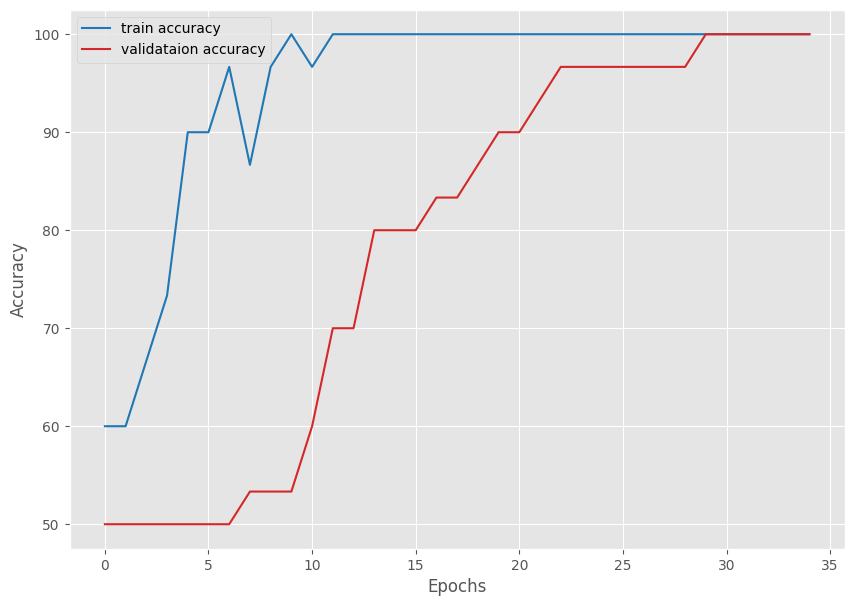

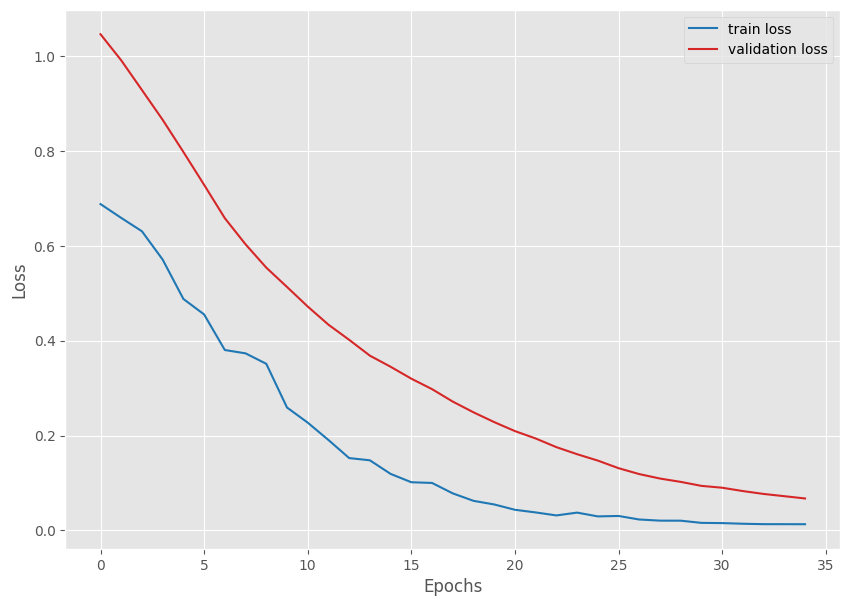

In [21]:
if __name__ == '__main__':
    # Load the training and validation datasets.
    dataset_train, dataset_valid, dataset_classes = get_datasets()
    print(f"[INFO]: Number of training images: {len(dataset_train)}")
    print(f"[INFO]: Number of validation images: {len(dataset_valid)}")
    print(f"[INFO]: Classes: {dataset_classes}")
    # Load the training and validation data loaders.
    train_loader, valid_loader = get_data_loaders(dataset_train, dataset_valid)

    # Learning_parameters.
    lr = args['learning_rate']
    epochs = args['epochs']
    device = ('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Computation device: {device}")
    print(f"Learning rate: {lr}")
    print(f"Epochs to train for: {epochs}\n")

    # Load the model.
    model = build_model(
        pretrained=True,
        fine_tune=True,
        num_classes=len(dataset_classes)
    ).to(device)

    # Total parameters and trainable parameters.
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{total_params:,} total parameters.")
    total_trainable_params = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{total_trainable_params:,} training parameters.")

    # Optimizer.
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    # Loss function.
    criterion = nn.CrossEntropyLoss()

    # Lists to keep track of losses and accuracies.
    train_loss, valid_loss = [], []
    train_acc, valid_acc = [], []
    # Start the training.
    for epoch in range(epochs):
        print(f"[INFO]: Epoch {epoch+1} of {epochs}")
        train_epoch_loss, train_epoch_acc = train(model, train_loader,
                                                optimizer, criterion)
        valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,
                                                    criterion, dataset_classes)
        train_loss.append(train_epoch_loss)
        valid_loss.append(valid_epoch_loss)
        train_acc.append(train_epoch_acc)
        valid_acc.append(valid_epoch_acc)
        print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
        print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
        print('-'*50)
        time.sleep(2)

    # Save the trained model weights.
    save_model(epochs, model, optimizer, criterion)
    # Save the loss and accuracy plots.
    save_plots(train_acc, valid_acc, train_loss, valid_loss)
    print('TRAINING COMPLETE')